In [37]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
import xgboost as xgb
from matplotlib import pyplot as plt
import numpy as np
np.random.seed(10)
from sklearn.naive_bayes import BernoulliNB



# import xgboost as xgb

In [2]:
X,y=load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [3]:
rf=RandomForestClassifier()
tree=DecisionTreeClassifier()

In [4]:
rf.fit(X_train,y_train)
tree.fit(X_train,y_train)

DecisionTreeClassifier()

In [5]:
rf.feature_importances_

array([0.05389058, 0.01478047, 0.04459252, 0.03418111, 0.0085638 ,
       0.00970118, 0.03398228, 0.12330025, 0.00422101, 0.00396569,
       0.01321344, 0.00584194, 0.02339124, 0.01922982, 0.00394898,
       0.00504429, 0.00875373, 0.00393642, 0.00645505, 0.00605652,
       0.12609261, 0.02630751, 0.07064143, 0.10400464, 0.00980397,
       0.01915984, 0.02987886, 0.16429799, 0.01587836, 0.00688448])

In [6]:
predict=rf.predict(X_test)
tree_predict=tree.predict(X_test)
print(classification_report(y_test,predict))
print("**"*50)
print(classification_report(y_test,tree_predict))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

****************************************************************************************************
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        54
           1       0.97      0.93      0.95        89

    accuracy                           0.94       143
   macro avg       0.93      0.94      0.93       143
weighted avg       0.94      0.94      0.94       143



In [7]:
svm=SVC()
tree=DecisionTreeClassifier()
lr=LogisticRegression(max_iter=4000)
knn=KNeighborsClassifier()
rf=RandomForestClassifier()
vc=VotingClassifier(estimators=[('svm',svm),
                                ('tree',tree),
                                ('lr',lr),
                               ('knn',knn),
                               ('rf',rf)])

In [8]:
vc.fit(X_train,y_train)

VotingClassifier(estimators=[('svm', SVC()), ('tree', DecisionTreeClassifier()),
                             ('lr', LogisticRegression(max_iter=4000)),
                             ('knn', KNeighborsClassifier()),
                             ('rf', RandomForestClassifier())])

In [9]:
predict=vc.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        54
           1       0.97      1.00      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



# XGBOOST

In [34]:
xgbClassifier=xgb.XGBClassifier()
xgbClassifier.fit(X_train,y_train)

In [11]:
xgbClassifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
predict=xgbClassifier.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



# Image Data

In [13]:
from sklearn.datasets import load_digits

In [33]:
X,y=load_digits(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [16]:
X[0].shape

(64,)

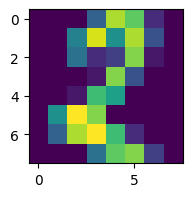

In [21]:
plt.figure(figsize=(2,2))
plt.imshow(X[50].reshape(8,8))

In [35]:
xgbClassifier=xgb.XGBClassifier()
xgbClassifier.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [36]:
predict=xgbClassifier.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       0.97      1.00      0.99        37
           2       0.95      1.00      0.97        38
           3       1.00      0.93      0.97        46
           4       0.98      0.98      0.98        55
           5       0.97      0.98      0.97        59
           6       0.98      0.98      0.98        45
           7       0.98      0.98      0.98        41
           8       0.95      0.97      0.96        38
           9       0.98      0.96      0.97        48

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



# Naive Bayes

In [38]:
X,y=load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [40]:
nb.fit(X_train,y_train)

BernoulliNB()

In [41]:
predict=nb.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        54
           1       0.62      1.00      0.77        89

    accuracy                           0.62       143
   macro avg       0.31      0.50      0.38       143
weighted avg       0.39      0.62      0.48       143



C:\Users\HP Zbook Fury 15 G7\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Zbook Fury 15 G7\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP Zbook Fury 15 G7\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont